In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

days = 180
dates = pd.date_range(start="2024-01-01", periods=days)

sources = ["Organic", "Paid Ads", "Social Media", "Referral"]

data = []

In [4]:
for i in range(days):
    visits = np.random.randint(1000, 5000)
    signups = int(visits * np.random.uniform(0.1, 0.3))
    purchases = int(signups * np.random.uniform(0.2, 0.5))

    data.append({
        "date": dates[i],
        "visits": visits,
        "signups": signups,
        "purchases": purchases,
        "traffic_source": np.random.choice(sources)
    })

df=pd.DataFrame(data)
df.head()

,date,visits,signups,purchases,traffic_source
0,2024-01-01,4174,1082,275,Referral
1,2024-01-02,4772,1046,349,Social Media
2,2024-01-03,1330,255,76,Referral
3,2024-01-04,4735,1089,236,Referral
4,2024-01-05,2515,723,144,Referral


In [5]:
df["visit_to_signup"] = df["signups"] / df["visits"]
df["signup_to_purchase"] = df["purchases"] / df["signups"]
df["overall_conversion"] = df["purchases"] / df["visits"]

In [6]:
source_perf = df.groupby("traffic_source")[["visit_to_signup","signup_to_purchase"]].mean()

print(source_perf.sort_values(by="signup_to_purchase", ascending=False))

                visit_to_signup  signup_to_purchase
traffic_source                                     
Paid Ads               0.198751            0.353551
Referral               0.204279            0.347593
Organic                0.217144            0.345682
Social Media           0.214252            0.331056


In [7]:
noise = np.random.normal(0, 0.02, len(df))

df["simulated_conversion"] = df["overall_conversion"] + noise
df["simulated_conversion"] = np.clip(df["simulated_conversion"], 0, 1)

In [8]:
mean_conv = np.mean(df["overall_conversion"])

drop_prob = np.mean(df["overall_conversion"] < mean_conv)

print("Probability of drop:", drop_prob)

Probability of drop: 0.5277777777777778


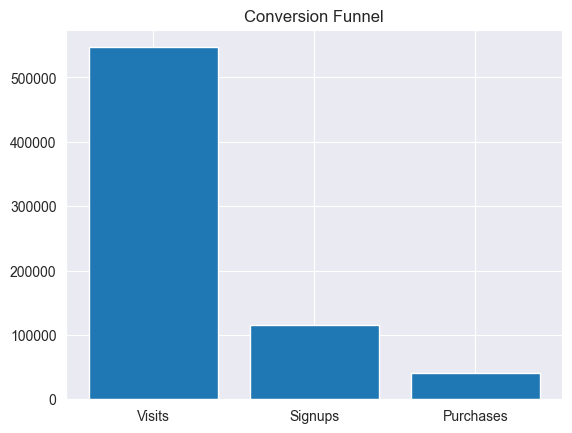

In [10]:


funnel = [
    df["visits"].sum(),
    df["signups"].sum(),
    df["purchases"].sum()
]

labels = ["Visits", "Signups", "Purchases"]

plt.bar(labels, funnel)
plt.title("Conversion Funnel")
plt.show()

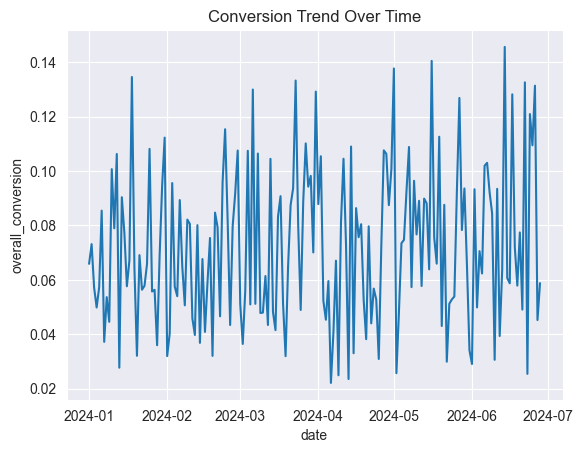

In [11]:


sns.lineplot(x="date", y="overall_conversion", data=df)
plt.title("Conversion Trend Over Time")
plt.show()